<a href="https://colab.research.google.com/github/Khalimovgeek/Tensorflow_MINI_PROJECTS/blob/main/NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install tensorflow-datasets

In [3]:
pip install --upgrade --force-reinstall tensorflow-datasets


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.5/186.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.1 MB/s eta 0:00:00


In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, datasets, optimizers, metrics, utils

In [2]:
(ds_train, ds_valid, ds_test), ds_info = tfds.load(
    'conll2003',
    split=['train', 'dev', 'test'],
    shuffle_files=True,
    with_info=True
)

# View dataset structure and total elements
print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating dev examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/conll2003/conll2003/incomplete.WVSUXN_1.0.0/conll2003-dev.tfrecord-[0-9][0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/conll2003/conll2003/incomplete.WVSUXN_1.0.0/conll2003-test.tfrecord-[0-9][…

Dataset conll2003 downloaded and prepared to /root/tensorflow_datasets/conll2003/conll2003/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='conll2003',
    full_name='conll2003/conll2003/1.0.0',
    description="""
    The shared task of CoNLL-2003 concerns language-independent named entity
    recognition and concentrates on four types of named entities: persons,
    locations, organizations and names of miscellaneous entities that do not belong
    to the previous three groups.
    """,
    homepage='https://www.aclweb.org/anthology/W03-0419/',
    data_dir='/root/tensorflow_datasets/conll2003/conll2003/1.0.0',
    file_format=tfrecord,
    download_size=959.94 KiB,
    dataset_size=3.87 MiB,
    features=FeaturesDict({
        'chunks': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=23)),
        'ner': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=9)),
        'pos': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=47)),
        

In [20]:
# Extract tokens and NER labels, and filter out empty sentences
ds_train_tuple = ds_train.map(lambda x: (x['tokens'], x['ner'])).filter(lambda tokens, labels: tf.shape(tokens)[0] > 0)
ds_val_tuple = ds_valid.map(lambda x: (x['tokens'], x['ner'])).filter(lambda tokens, labels: tf.shape(tokens)[0] > 0)

In [51]:
MAX_TOKENS = 10000
SEQUNCE_LEN = 200
vectorize_layer = layers.TextVectorization(max_tokens=MAX_TOKENS,output_mode='int',output_sequence_length=SEQUNCE_LEN, split = None , standardize = None)


In [59]:
# Extract only the text tokens for adaptation
train_text = ds_train_tuple.map(lambda tokens, labels: tokens)
vectorize_layer.adapt(train_text)

In [60]:
import tensorflow as tf

def preprocess_fn(tokens, labels):
    # 1. Add a temporary batch dimension so the vectorizer treats this as ONE sentence
    # Shape changes from (seq_len,) to (1, seq_len)
    expanded_tokens = tf.expand_dims(tokens, axis=0)

    # 2. Vectorize (outputs shape (1, SEQUENCE_LEN))
    vectorized_2d = vectorize_layer(expanded_tokens)

    # 3. Remove the temporary batch dimension (outputs shape (SEQUENCE_LEN,))
    vectorized_tokens = tf.squeeze(vectorized_2d, axis=0)

    # 4. Pad or truncate labels to match SEQUENCE_LEN
    seq_len = tf.shape(labels)[0]
    pad_size = tf.maximum(0, SEQUNCE_LEN - seq_len)
    padded_labels = tf.pad(labels, [[0, pad_size]], constant_values=0)
    final_labels = padded_labels[:SEQUNCE_LEN]

    return vectorized_tokens, final_labels

In [61]:

print(ds_train.cardinality())

tf.Tensor(14042, shape=(), dtype=int64)


In [62]:
# Map the preprocessing function and set batch size
train_dataset = ds_train_tuple.map(preprocess_fn).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = ds_val_tuple.map(preprocess_fn).batch(32).prefetch(tf.data.AUTOTUNE)

In [63]:
import tensorflow as tf

def crf_sequence_score(inputs, tag_indices, sequence_lengths, transition_params):
    """Computes the path score of the gold-standard tag sequences."""
    batch_size = tf.shape(inputs)[0]
    max_seq_len = tf.shape(inputs)[1]

    # 1. Unary scores (emissions along the gold path)
    batch_index = tf.tile(tf.expand_dims(tf.range(batch_size), axis=1), [1, max_seq_len])
    time_index = tf.tile(tf.expand_dims(tf.range(max_seq_len), axis=0), [batch_size, 1])
    indices = tf.stack([batch_index, time_index, tag_indices], axis=-1)

    vectorized_tokens = tf.gather_nd(inputs, indices)

    # Apply masking
    mask = tf.sequence_mask(sequence_lengths, maxlen=max_seq_len, dtype=tf.float32)
    unary_score = tf.reduce_sum(vectorized_tokens * mask, axis=-1)

    # 2. Binary scores (transitions along the gold path)
    start_tags = tag_indices[:, :-1]
    end_tags = tag_indices[:, 1:]
    transition_indices = tf.stack([start_tags, end_tags], axis=-1)
    binary_scores = tf.gather_nd(transition_params, transition_indices)

    transition_mask = tf.sequence_mask(
        tf.maximum(0, sequence_lengths - 1), maxlen=max_seq_len - 1, dtype=tf.float32
    )
    binary_score = tf.reduce_sum(binary_scores * transition_mask, axis=-1)

    return unary_score + binary_score


def crf_log_norm(inputs, sequence_lengths, transition_params):
    # Calculates Z (normalizer) via dynamic programming using tf.while_loop
    batch_size = tf.shape(inputs)[0]
    max_seq_len = tf.shape(inputs)[1]

    inputs_t = tf.transpose(inputs, [1, 0, 2])
    alpha_0 = inputs_t[0]

    alphas = tf.TensorArray(dtype=tf.float32, size=max_seq_len)
    alphas = alphas.write(0, alpha_0)

    def scan_fn(alpha, emission):
        alpha_ex = tf.expand_dims(alpha, axis=2)
        trans_ex = tf.expand_dims(transition_params, axis=0)
        emission_ex = tf.expand_dims(emission, axis=1)
        next_alpha = alpha_ex + trans_ex + emission_ex
        return tf.reduce_logsumexp(next_alpha, axis=1)

    t = tf.constant(1, dtype=tf.int32)

    # Explicit loop condition and body
    def cond(t, alpha, alphas):
        return t < max_seq_len

    def body(t, alpha, alphas):
        emission = inputs_t[t]
        next_alpha = scan_fn(alpha, emission)
        mask = tf.expand_dims(tf.cast(t < sequence_lengths, tf.float32), axis=-1)
        alpha = mask * next_alpha + (1.0 - mask) * alpha
        alphas = alphas.write(t, alpha)
        return t + 1, alpha, alphas

    _, _, alphas = tf.while_loop(cond, body, [t, alpha_0, alphas])

    alphas = tf.transpose(alphas.stack(), [1, 0, 2])
    batch_indices = tf.range(batch_size)
    gather_indices = tf.stack([batch_indices, tf.maximum(0, sequence_lengths - 1)], axis=-1)
    final_alphas = tf.gather_nd(alphas, gather_indices)

    return tf.reduce_logsumexp(final_alphas, axis=-1)


def crf_log_likelihood(inputs, tag_indices, sequence_lengths, transition_params):
    gold_score = crf_sequence_score(inputs, tag_indices, sequence_lengths, transition_params)
    partition = crf_log_norm(inputs, sequence_lengths, transition_params)
    return gold_score - partition


def crf_decode(inputs, transition_params, sequence_lengths):
    # Dynamic Viterbi decoding using tf.while_loops (forward & backward traceback)
    batch_size = tf.shape(inputs)[0]
    max_seq_len = tf.shape(inputs)[1]

    inputs_t = tf.transpose(inputs, [1, 0, 2])
    viterbi = inputs_t[0]

    viterbis = tf.TensorArray(dtype=tf.float32, size=max_seq_len)
    viterbis = viterbis.write(0, viterbi)
    backpointers = tf.TensorArray(dtype=tf.int32, size=max_seq_len)

    # 1. Forward Pass tf.while_loop
    t = tf.constant(1, dtype=tf.int32)

    def cond_forward(t, viterbi, viterbis, backpointers):
        return t < max_seq_len

    def body_forward(t, viterbi, viterbis, backpointers):
        emission = inputs_t[t]
        viterbi_ex = tf.expand_dims(viterbi, axis=2)
        trans_ex = tf.expand_dims(transition_params, axis=0)
        next_viterbi = viterbi_ex + trans_ex

        bp = tf.argmax(next_viterbi, axis=1, output_type=tf.int32)
        backpointers = backpointers.write(t, bp)

        max_viterbi = tf.reduce_max(next_viterbi, axis=1)
        next_viterbi_val = max_viterbi + emission

        mask = tf.expand_dims(tf.cast(t < sequence_lengths, tf.float32), axis=-1)
        next_viter = mask * next_viterbi_val + (1.0 - mask) * viterbi
        viterbis = viterbis.write(t, next_viter)
        return t + 1, next_viter, viterbis, backpointers

    _, _, viterbis, backpointers = tf.while_loop(
        cond_forward, body_forward, [t, viterbi, viterbis, backpointers]
    )

    viterbis = tf.transpose(viterbis.stack(), [1, 0, 2])
    backpointers = tf.transpose(backpointers.stack(), [1, 0, 2])

    # 2. Extract best final state
    batch_indices = tf.range(batch_size)
    last_viterbi_indices = tf.stack([batch_indices, tf.maximum(0, sequence_lengths - 1)], axis=-1)
    last_viterbi = tf.gather_nd(viterbis, last_viterbi_indices)
    best_last_tag = tf.argmax(last_viterbi, axis=-1, output_type=tf.int32)

    # 3. Dynamic Backtrack tf.while_loop
    path = tf.TensorArray(dtype=tf.int32, size=max_seq_len)
    t_back = max_seq_len - 1
    state_tag = best_last_tag

    def cond_backward(t_back, state_tag, path):
        return t_back >= 0

    def body_backward(t_back, state_tag, path):
        is_last = tf.equal(t_back, sequence_lengths - 1)
        is_active = tf.less(t_back, sequence_lengths - 1)

        # Clip index to avoid out-of-bounds at the very last step t_back + 1
        safe_t_back = tf.minimum(t_back + 1, max_seq_len - 1)
        bp_t = backpointers[:, safe_t_back]

        batch_indices = tf.range(batch_size)
        gather_idx = tf.stack([batch_indices, state_tag], axis=-1)
        next_tag = tf.gather_nd(bp_t, gather_idx)

        next_state_tag = tf.where(is_last, best_last_tag,
                                 tf.where(is_active, next_tag, tf.zeros_like(state_tag)))
        path = path.write(t_back, next_state_tag)
        return t_back - 1, next_state_tag, path

    _, _, path = tf.while_loop(cond_backward, body_backward, [t_back, state_tag, path])

    return tf.transpose(path.stack(), [1, 0])

In [64]:
class CRFModel(models.Model):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base_model = base_model
        self.num_classes = num_classes
        # Trainable transition matrix of shape [num_classes, num_classes]
        self.transition_params = self.add_weight(
            name="transition_params",
            shape=(num_classes, num_classes),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs, training=None):
        # Forward pass to get raw emissions (logits)
        emissions = self.base_model(inputs, training=training)
        return emissions

    def compute_loss(self, x, y, y_pred, sample_weight=None):
        # Calculate sequence lengths from padded inputs (ignores 0 padding)
        sequence_lengths = tf.reduce_sum(tf.cast(tf.not_equal(x, 0), tf.int32), axis=-1)

        # Ensure label tensor is 2D and int32
        y = tf.cast(y, tf.int32)
        if len(y.shape) == 3:
            y = tf.squeeze(y, axis=-1)

        # CRF log-likelihood loss calculation using our custom helper
        log_likelihood = crf_log_likelihood(
            inputs=y_pred,
            tag_indices=y,
            sequence_lengths=sequence_lengths,
            transition_params=self.transition_params
        )
        # Minimize the negative log likelihood
        return tf.reduce_mean(-log_likelihood)

    def predict_step(self, data):
        # Unpack batch data
        x, _, _ = tf.keras.utils.unpack_x_y_sample_weight(data)

        # Get emissions
        emissions = self(x, training=False)

        # Calculate sequence lengths
        sequence_lengths = tf.reduce_sum(tf.cast(tf.not_equal(x, 0), tf.int32), axis=-1)

        # Viterbi decoding using our custom helper
        decode_tags = crf_decode(
            emissions, self.transition_params, sequence_lengths
        )
        return decode_tags

In [65]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_ner_classifier_weights.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)


In [66]:
# 1. Base Sequential Model (Note the final Dense layer has activation=None)
base_model = models.Sequential([
    layers.Embedding(input_dim=len(vectorize_layer.get_vocabulary()), output_dim=32, mask_zero=True, input_shape=(SEQUNCE_LEN,)),
    layers.Bidirectional(layers.LSTM(32, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32, return_sequences=True)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(9, activation=None),  # <--- MUST be raw logits (no softmax)
])

# 2. Wrap with the CRF wrapper
crf_model = CRFModel(base_model, num_classes=9)

# 3. Compile
crf_model.compile(
    optimizer='adam',
    metrics=['accuracy']
)

# 4. Update Callback for Custom Models
# Custom models are safest saved as weights-only to prevent Keras 3 serialization warnings
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_ner_classifier_weights.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)

# 5. Fit
history = crf_model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
    439/Unknown 178s 392ms/step - accuracy: 0.8228 - loss: 12.3768

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


439/439 ━━━━━━━━━━━━━━━━━━━━ 186s 410ms/step - accuracy: 0.8354 - loss: 9.0675 - val_accuracy: 0.8544 - val_loss: 5.2822
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 174s 396ms/step - accuracy: 0.8940 - loss: 3.4517 - val_accuracy: 0.8985 - val_loss: 3.6786
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 172s 392ms/step - accuracy: 0.9321 - loss: 2.2669 - val_accuracy: 0.9248 - val_loss: 3.0327
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 395ms/step - accuracy: 0.9563 - loss: 1.5415 - val_accuracy: 0.9357 - val_loss: 2.8901
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 174s 397ms/step - accuracy: 0.9674 - loss: 1.1294 - val_accuracy: 0.9428 - val_loss: 2.5531
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 202s 397ms/step - accuracy: 0.9723 - loss: 0.9082 - val_accuracy: 0.9423 - val_loss: 2.5657
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 175s 397ms/step - accuracy: 0.9766 - loss: 0.7465 - val_accuracy: 0.9427 - val_loss: 2.7893
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 213s 486ms/step - accuracy: 0.9805 - loss: 0.62

In [28]:
def predict_custom_sentence(sentence_str, model, vectorize_layer, tag_names):
    # Split tokens
    tokens = re.findall(r"\w+|[^\w\s]", sentence_str)
    tokens_tensor = tf.constant(tokens)

    # Vectorize
    vectorized_input = vectorize_layer(tf.expand_dims(tokens_tensor, axis=0))

    # Model now returns Viterbi decoded paths directly!
    predicted_ids = model.predict(vectorized_input)[0]  # Extracts the first batch item

    # Print the results
    print(f"\n--- Custom Prediction for: '{sentence_str}' ---")
    print(f"{'Token':<15} | {'Predicted Tag':<15}")
    print("-" * 35)

    for token, pred_id in zip(tokens, predicted_ids):
        pred_tag = tag_names[pred_id]
        print(f"{token:<15} | {pred_tag:<15}")

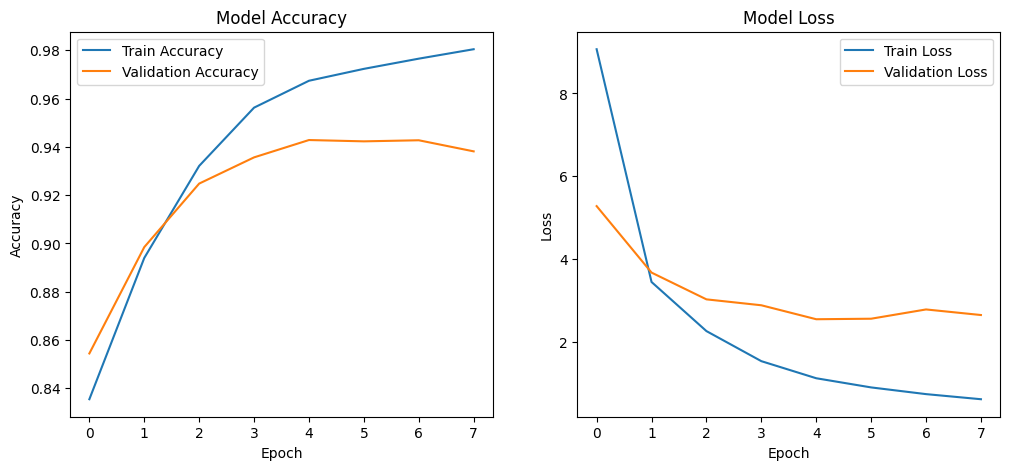

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [68]:
# 1. Map the raw test dataset and filter out empty sentences
ds_test_tuple = ds_test.map(lambda x: (x['tokens'], x['ner'])).filter(lambda tokens, labels: tf.shape(tokens)[0] > 0)

# 2. Run the preprocessing function and batch the data
test_dataset = ds_test_tuple.map(preprocess_fn).batch(32).prefetch(tf.data.AUTOTUNE)

# 3. Evaluate the model on the test dataset
test_loss, test_accuracy = crf_model.evaluate(test_dataset)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9244 - loss: 3.0446

Test Loss: 3.0446
Test Accuracy: 0.9244


In [74]:
import numpy as np

# Retrieve vocabulary and tag class names from TFDS info
vocabulary = vectorize_layer.get_vocabulary()
tag_names = ds_info.features['ner'].feature.names  # e.g., ['O', 'B-PER', 'I-PER', ...]

# Take 1 batch from the test dataset to inspect
for x_batch, y_batch in test_dataset.take(1):
    # Predict the probability distributions
    raw_predictions = crf_model.predict(x_batch)

    # Get the index of the highest probability for each token
    predicted_ids = np.argmax(raw_predictions, axis=-1)

    # Let's inspect the first 5 sentences in this batch
    for i in range(5):
        print(f"\n--- Sentence {i + 1} ---")
        print(f"{'Word':<15} | {'True Tag':<10} | {'Predicted Tag':<10}")
        print("-" * 43)

        sentence_tokens = x_batch[i].numpy()
        true_tags = y_batch[i].numpy()
        pred_tags = predicted_ids[i]

        for token_id, true_id, pred_id in zip(sentence_tokens, true_tags, pred_tags):
            # Skip padding tokens (the vectorizer maps padding to index 0)
            if token_id == 0:
                continue

            word = vocabulary[token_id]
            true_tag = tag_names[true_id]
            pred_tag = tag_names[pred_id]

            # Print row if it's not padding
            print(f"{word:<15} | {true_tag:<10} | {pred_tag:<10}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step

--- Sentence 1 ---
Word            | True Tag   | Predicted Tag
-------------------------------------------


TypeError: 'numpy.int64' object is not iterable

In [ ]:
  model = models.load('best_ner_classifier.keras')


In [71]:
import numpy as np
import re
import tensorflow as tf

def predict_custom_sentence(sentence_str, model, vectorize_layer, tag_names):
    # 1. Split words and punctuation cleanly
    tokens = re.findall(r"\w+|[^\w\s]", sentence_str)
    tokens_tensor = tf.constant(tokens)

    # 2. Vectorize inputs
    vectorized_input = vectorize_layer(tf.expand_dims(tokens_tensor, axis=0))

    # 3. Model prediction
    predictions = model.predict(vectorized_input)

    # 4. Squeeze to safely guarantee a 1D array of shape (SEQUENCE_LEN,)
    predicted_ids = np.squeeze(predictions)

    # 5. Print results
    print(f"\n--- Custom Prediction for: '{sentence_str}' ---")
    print(f"{'Token':<15} | {'Predicted Tag':<15}")
    print("-" * 35)

    # Zipping with tokens automatically ignores all trailing padding tag IDs
    for token, pred_id in zip(tokens, predicted_ids):
        pred_tag = tag_names[pred_id]
        print(f"{token:<15} | {pred_tag:<15}")

In [73]:


# Retrieve your vocabulary and tag class names if not already in memory
vocabulary = vectorize_layer.get_vocabulary()
tag_names = ds_info.features['ner'].feature.names  # ['O', 'B-PER', 'I-PER', ...]


# --- Run the Custom Inference ---
test_sentences = [
    "Elon Musk announced that SpaceX will launch a new rocket from Cape Canaveral.",
    "Yesterday, Sundar Pichai attended a technology conference in Munich to represent Google.",
    "The United Nations will meet in Geneva to discuss the European trade agreement."
]

for sentence in test_sentences:
    predict_custom_sentence(sentence, crf_model, vectorize_layer, tag_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step

--- Custom Prediction for: 'Elon Musk announced that SpaceX will launch a new rocket from Cape Canaveral.' ---
Token           | Predicted Tag  
-----------------------------------


TypeError: 'numpy.int64' object is not iterable

In [75]:
import numpy as np
import re
import tensorflow as tf

# Retrieve your vocabulary and tag class names if not in memory
vocabulary = vectorize_layer.get_vocabulary()
tag_names = ds_info.features['ner'].feature.names  # ['O', 'B-PER', 'I-PER', ...]

def predict_custom_sentence(sentence_str, model, vectorize_layer, tag_names):
    # 1. Cleanly split words and punctuation
    tokens = re.findall(r"\w+|[^\w\s]", sentence_str)
    tokens_tensor = tf.constant(tokens)

    # 2. Vectorize inputs (shape: 1, 200)
    vectorized_input = vectorize_layer(tf.expand_dims(tokens_tensor, axis=0))

    # 3. Direct forward pass through the model to get raw emissions
    emissions = model(vectorized_input, training=False)

    # 4. Calculate sequence lengths (unmasked tokens)
    sequence_lengths = tf.reduce_sum(tf.cast(tf.not_equal(vectorized_input, 0), tf.int32), axis=-1)

    # 5. Decode directly using our custom Viterbi crf_decode helper
    decoded_tags = crf_decode(emissions, model.transition_params, sequence_lengths)

    # 6. Extract the 1D predicted IDs array (guaranteed shape: (200,))
    predicted_ids = decoded_tags.numpy()[0]

    # 7. Print results
    print(f"\n--- Custom Prediction for: '{sentence_str}' ---")
    print(f"{'Token':<15} | {'Predicted Tag':<15}")
    print("-" * 35)

    # Zipping with tokens automatically ignores all trailing padding tag IDs
    for token, pred_id in zip(tokens, predicted_ids):
        pred_tag = tag_names[pred_id]
        print(f"{token:<15} | {pred_tag:<15}")

# --- Run the Custom Inference ---
test_sentences = [
    "Elon Musk announced that SpaceX will launch a new rocket from Cape Canaveral.",
    "Yesterday, Sundar Pichai attended a technology conference in Munich to represent Google.",
    "The United Nations will meet in Geneva to discuss the European trade agreement."
]

for sentence in test_sentences:
    predict_custom_sentence(sentence, crf_model, vectorize_layer, tag_names)


--- Custom Prediction for: 'Elon Musk announced that SpaceX will launch a new rocket from Cape Canaveral.' ---
Token           | Predicted Tag  
-----------------------------------
Elon            | O              
Musk            | O              
announced       | O              
that            | O              
SpaceX          | O              
will            | O              
launch          | O              
a               | O              
new             | O              
rocket          | O              
from            | O              
Cape            | O              
Canaveral       | O              
.               | O              

--- Custom Prediction for: 'Yesterday, Sundar Pichai attended a technology conference in Munich to represent Google.' ---
Token           | Predicted Tag  
-----------------------------------
Yesterday       | O              
,               | O              
Sundar          | B-PER          
Pichai          | I-PER          
attended     